<a href="https://colab.research.google.com/github/Deyanet001/Machine-Learning-Projects/blob/main/knn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Load the Dataset


In [2]:
#!/bin/bash
!curl -L -o knn-algorithm-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/gkalpolukcu/knn-algorithm-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 49826  100 49826    0     0  76300      0 --:--:-- --:--:-- --:--:-- 76300


In [3]:
!unzip /content/knn-algorithm-dataset.zip

Archive:  /content/knn-algorithm-dataset.zip
  inflating: KNNAlgorithmDataset.csv  


In [4]:
# Step 1: Load the Dataset
dataset_path = '/content/KNNAlgorithmDataset.csv'
data = pd.read_csv(dataset_path)

# Display the first few rows of the dataset


In [5]:
# Display the first few rows of the dataset
print("First few rows of the dataset:\n")
print(data.head())

First few rows of the dataset:

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimet

# Step 2: Check for missing values


In [6]:
# Step 2: Check for missing values
print("Check for missing values:\n")
print(data.isnull().sum())

Check for missing values:

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dime

# Step 3: Display the data types of each column


In [7]:
# Step 3: Display the data types of each column
print("Data types of each column:\n")
print(data.dtypes)

Data types of each column:

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          

# 1. Distribution of the target variable


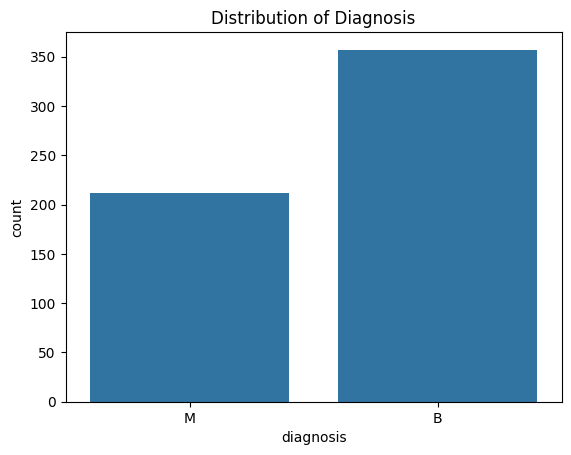

In [8]:
# 1. Distribution of the target variable
sns.countplot(x='diagnosis', data=data)
plt.title('Distribution of Diagnosis')
plt.show()

# 2. Distribution of mean radius


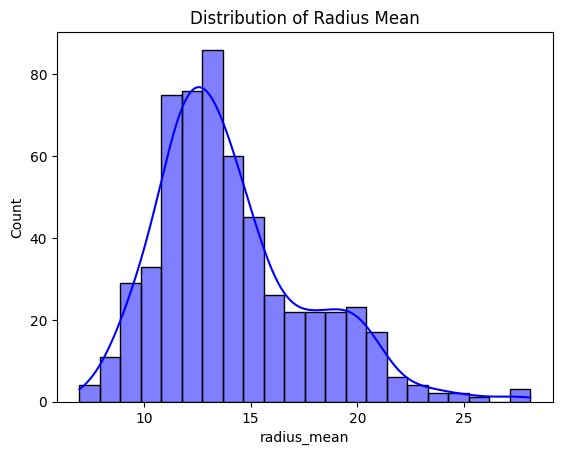

In [9]:
# 2. Distribution of mean radius
sns.histplot(data['radius_mean'], kde=True, color='blue')
plt.title('Distribution of Radius Mean')
plt.show()

# 3. Pairplot to visualize relationships between features


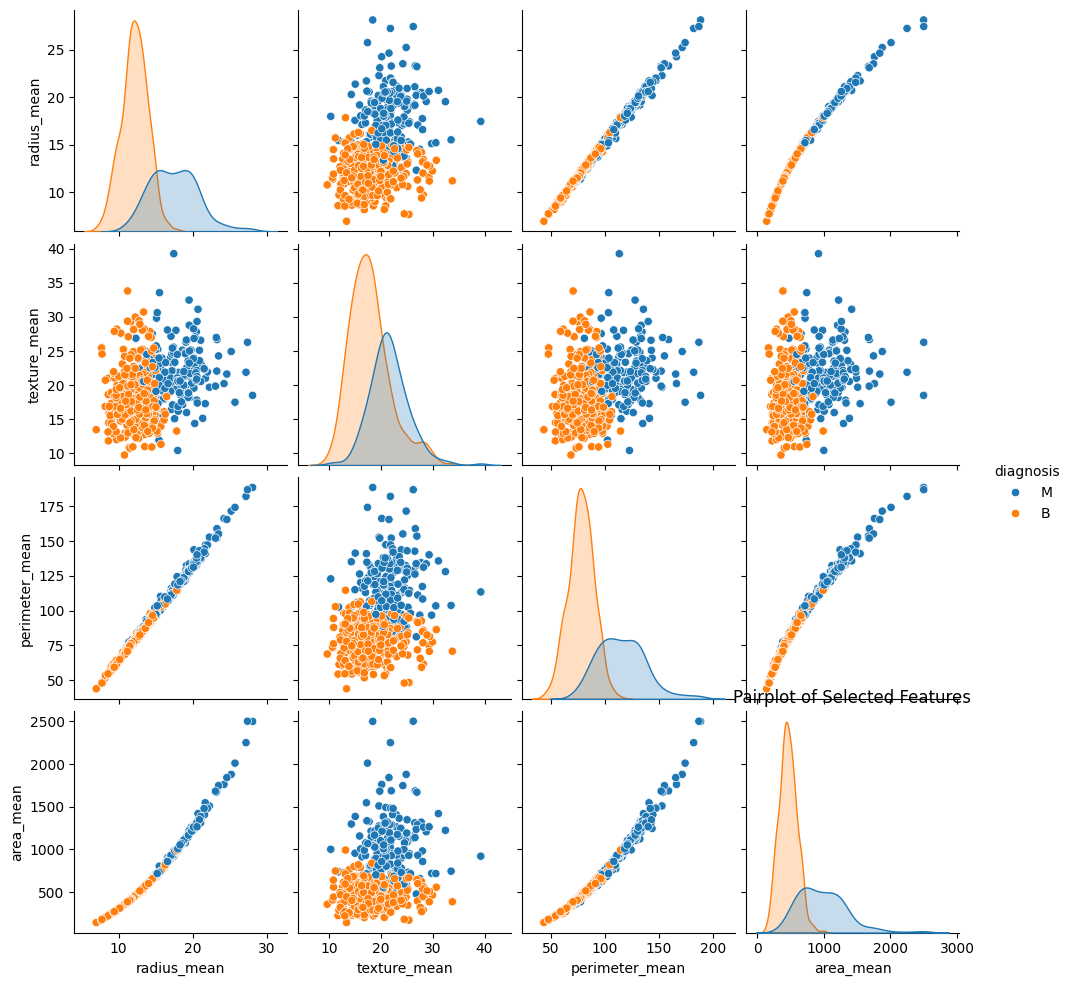

In [10]:
# 3. Pairplot to visualize relationships between features
sns.pairplot(data, hue='diagnosis', vars=['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean'])
plt.title('Pairplot of Selected Features')
plt.show()

# 4. Heatmap of correlation matrix


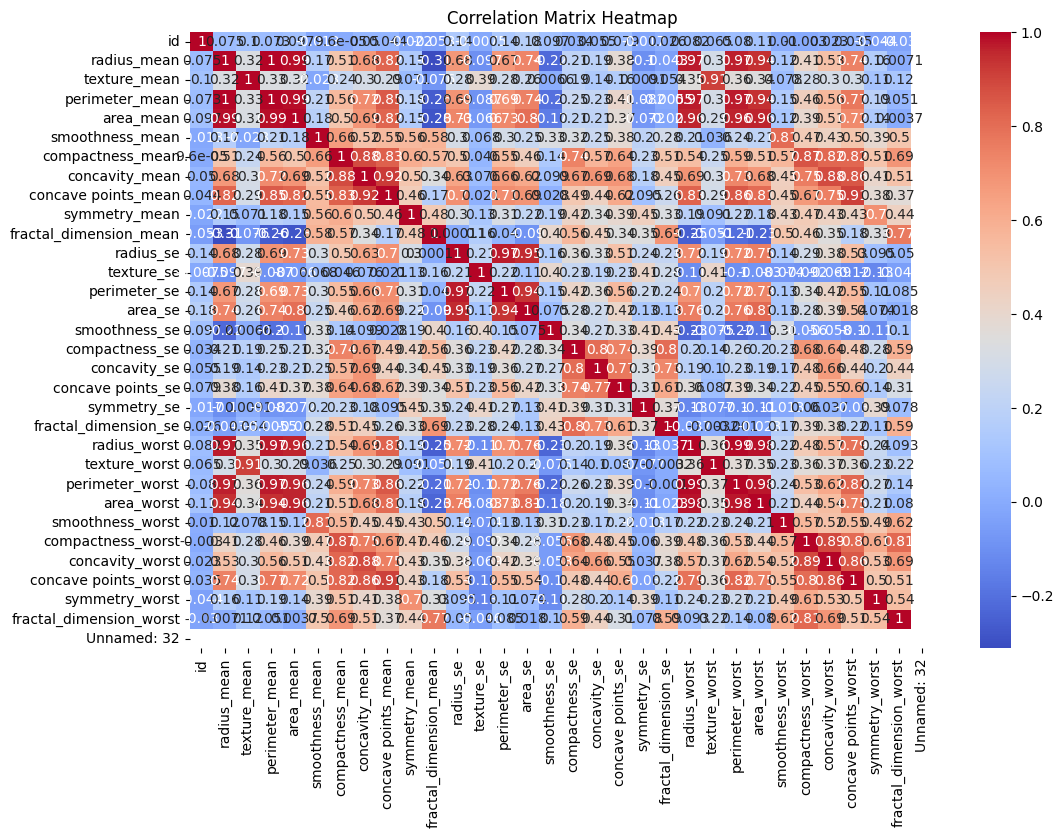

In [11]:
# 4. Heatmap of correlation matrix (excluding non-numeric columns)
plt.figure(figsize=(12, 8))

# Select only numeric columns for correlation
numeric_data = data.select_dtypes(include=[np.number])

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()


# 5. Boxplot of radius_mean by diagnosis


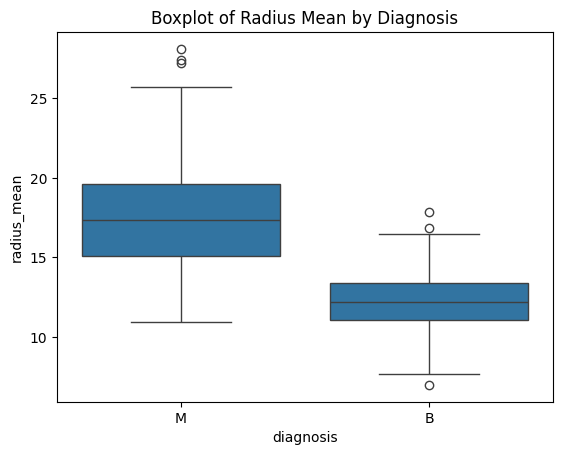

In [12]:
# 5. Boxplot of radius_mean by diagnosis
sns.boxplot(x='diagnosis', y='radius_mean', data=data)
plt.title('Boxplot of Radius Mean by Diagnosis')
plt.show()

# 6. Violin plot of texture_mean by diagnosis


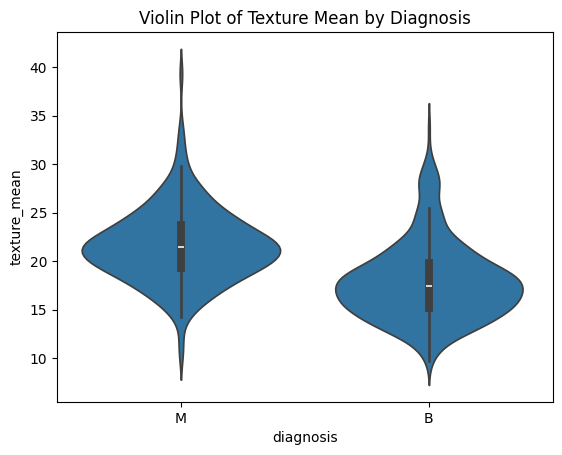

In [13]:
# 6. Violin plot of texture_mean by diagnosis
sns.violinplot(x='diagnosis', y='texture_mean', data=data)
plt.title('Violin Plot of Texture Mean by Diagnosis')
plt.show()

# 7. Distribution of perimeter_mean


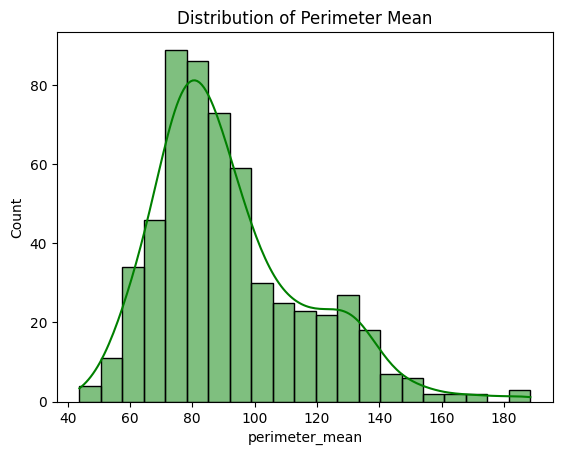

In [14]:
# 7. Distribution of perimeter_mean
sns.histplot(data['perimeter_mean'], kde=True, color='green')
plt.title('Distribution of Perimeter Mean')
plt.show()

# 8. Scatter plot of area_mean vs. perimeter_mean


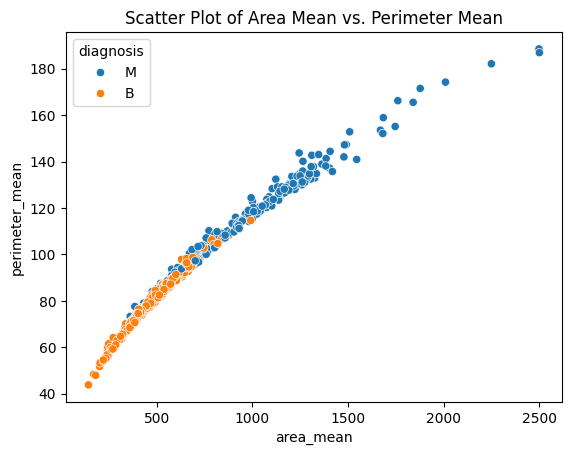

In [15]:
# 8. Scatter plot of area_mean vs. perimeter_mean
sns.scatterplot(x='area_mean', y='perimeter_mean', hue='diagnosis', data=data)
plt.title('Scatter Plot of Area Mean vs. Perimeter Mean')
plt.show()

# 9. Swarm plot of compactness_mean by diagnosis


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


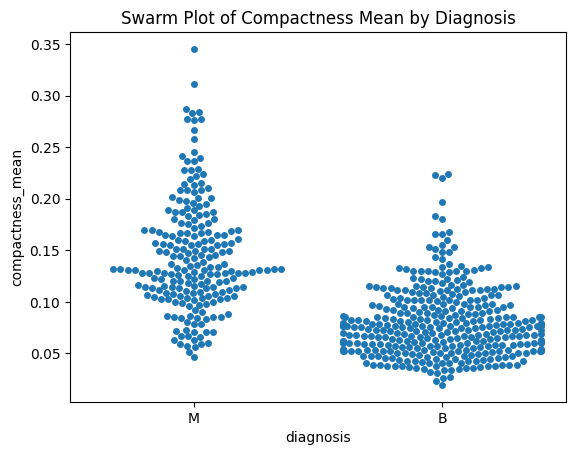

In [16]:
# 9. Swarm plot of compactness_mean by diagnosis
sns.swarmplot(x='diagnosis', y='compactness_mean', data=data)
plt.title('Swarm Plot of Compactness Mean by Diagnosis')
plt.show()

# 10. Pairplot of concavity_mean and concave points_mean


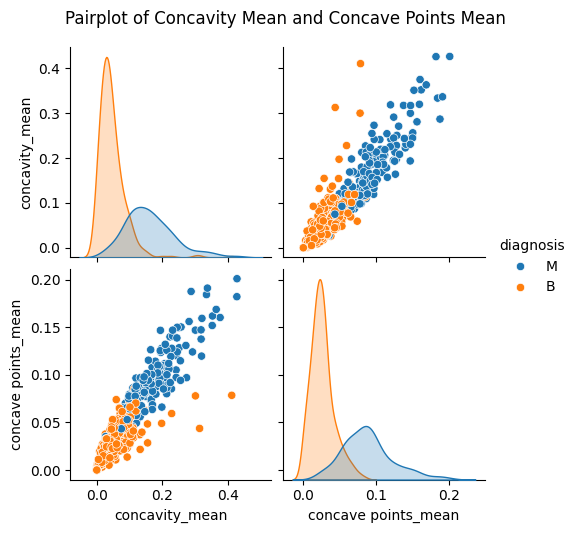

In [17]:
# 10. Pairplot of concavity_mean and concave points_mean
g = sns.pairplot(data,hue='diagnosis',vars=['concavity_mean', 'concave points_mean'])
g.fig.suptitle('Pairplot of Concavity Mean and Concave Points Mean', y=1.05)
plt.show()

# Step 3: Preprocessing


In [18]:
# Step 3: Preprocessing

# Dropping the id column as it is not needed
data = data.drop(columns=['id'])

# Encoding target variable
# Splitting the dataset into features and target


In [19]:
# Encoding target variable
data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1})

# Splitting the dataset into features and target
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# Splitting the dataset into training and testing sets


In [20]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
from sklearn.impute import SimpleImputer

# Impute missing values with the mean (you can choose other strategies like median or most_frequent)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


# Standardizing the features


In [22]:
# Standardizing the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Step 4: Model Implementation


In [23]:
# KNN Classifier
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights = 'uniform',    #uniform(butun qonsular eyni ceki) ve distance(yaxin qonsu daha cox desir edir)
    metric = 'minkowski',   #mesafenin nece hesablanmasi(euclidian(duz xett), manhattan(ufuqu ve saquli ist.), minkowski(p-den asilidir))
    p = 2                   # 1 - manhattan, 2 - Euclidean
    )
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [24]:
# Make predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [25]:
scores = []
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    score = accuracy_score(y_test, y_pred)

    scores.append(score)

best_k = scores.index(max(scores)) + 1

print("Ən yaxşı k:", best_k)
print("Ən yaxşı accuracy:", max(scores))

Ən yaxşı k: 9
Ən yaxşı accuracy: 0.9649122807017544


In [26]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

full_preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


full_pipeline = Pipeline(steps=[
    ("preprocessing", full_preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])


full_pipeline.fit(X_train, y_train)

y_pred = full_pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
